In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
print("All ML libraries loaded successfully")

All ML libraries loaded successfully


In [2]:
df = pd.read_csv('uae_properties_cleaned.csv')
print("shape:",df.shape)
print("Columns:",df.columns.tolist())
df.head()

shape: (492, 11)
Columns: ['title', 'displayAddress', 'bathrooms', 'bedrooms', 'addedOn', 'rera', 'price', 'year', 'month', 'month_name', 'area']


,title,displayAddress,bathrooms,bedrooms,addedOn,rera,price,year,month,month_name,area
0,★ EXCLUSIVE RELEASE ★ | LUXURY 3 BED FLAT | GO...,"Sobha One, Sobha Hartland, Mohammed Bin Rashid...",2,3,2024-01-06 17:05:24+00:00,8.171857e+08,3950000,2024,1,January,Mohammed Bin Rashid City
1,"★ BUY NOW 624,000AED ★ (20% FIRST PAYMENT + 4%...","Sobha Verde, Jumeirah Lake Towers, Dubai",2,3,2024-01-13 21:19:31+00:00,8.171857e+08,2600000,2024,1,January,Jumeirah Lake Towers
2,GREEN HEART OF DUBAI |URBAN DESIGN | LUXURY LI...,"Park Horizon, Dubai Hills Estate, Dubai",2,3,2024-03-12 03:18:54+00:00,2.125966e+09,3450000,2024,3,March,Dubai Hills Estate
3,Prime Location | Corner Spacious Unit | Bright...,"AZIZI Riviera, Meydan One, Meydan, Dubai",2,3,2024-03-04 06:53:51+00:00,7.114978e+10,2000000,2024,3,March,Meydan
4,Very Limited | Ideal For Investment | 40% Disc...,"Verdana, Dubai Investment Park, Dubai",2,0,2024-03-04 13:24:39+00:00,4.652616e+08,284000,2024,3,March,Dubai Investment Park


In [3]:
#convert area to numbers
df["area_encoded"] = pd.factorize(df["area"]) [0]

#Select features
X=df[["bathrooms","bedrooms","area_encoded","month","year"]]

# Target
Y=df["price"]
print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("feature engineering done")
      
      
      



X shape: (492, 5)
Y shape: (492,)
feature engineering done


In [7]:

# Train Test split
X_train,X_test,y_train,y_test = train_test_split(X,Y,
test_size=0.2,
random_state=42)
print("Training size:",X_train.shape)
print("Testing size:",X_test.shape)
print("Train Test Split done!")

_

Training size: (393, 5)
Testing size: (99, 5)
Train Test Split done!


,title,displayAddress,bathrooms,bedrooms,addedOn,rera,price,year,month,month_name,area
0,★ EXCLUSIVE RELEASE ★ | LUXURY 3 BED FLAT | GO...,"Sobha One, Sobha Hartland, Mohammed Bin Rashid...",2,3,2024-01-06 17:05:24+00:00,8.171857e+08,3950000,2024,1,January,Mohammed Bin Rashid City
1,"★ BUY NOW 624,000AED ★ (20% FIRST PAYMENT + 4%...","Sobha Verde, Jumeirah Lake Towers, Dubai",2,3,2024-01-13 21:19:31+00:00,8.171857e+08,2600000,2024,1,January,Jumeirah Lake Towers
2,GREEN HEART OF DUBAI |URBAN DESIGN | LUXURY LI...,"Park Horizon, Dubai Hills Estate, Dubai",2,3,2024-03-12 03:18:54+00:00,2.125966e+09,3450000,2024,3,March,Dubai Hills Estate
3,Prime Location | Corner Spacious Unit | Bright...,"AZIZI Riviera, Meydan One, Meydan, Dubai",2,3,2024-03-04 06:53:51+00:00,7.114978e+10,2000000,2024,3,March,Meydan
4,Very Limited | Ideal For Investment | 40% Disc...,"Verdana, Dubai Investment Park, Dubai",2,0,2024-03-04 13:24:39+00:00,4.652616e+08,284000,2024,3,March,Dubai Investment Park


In [9]:
#Train Model
lr=LinearRegression()
lr.fit(X_train, y_train)

#predict
lr_pred =lr.predict(X_test)

#Evaluate 
lr_r2 = r2_score(y_test, lr_pred)
lr_mea = mean_absolute_error(y_test, lr_pred)
print("Linear Regression Results:")
print("R2 score:", round(lr_r2,2))
print("MAE:",round(lr_mea,2))


Linear Regression Results:
R2 score: 0.13
MAE: 1321782.88


In [10]:
#train model
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

#predict
rf_pred = rf.predict(X_test)
#Evaluate
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test , rf_pred)
print("Random Forest Results:")
print("R2 Score:", round(rf_r2,2))
print("MAE:", round(rf_mae,2))


Random Forest Results:
R2 Score: 0.47
MAE: 765208.12


In [11]:
#predict price of new property
new_property= pd.DataFrame({
    "bathrooms":[2],
    "bedrooms":[3],
    "area_encoded":[5],
    "month":[1],
    "year":[2024]
})
predicted_price = rf.predict(new_property)
print("Predicted Price:")
print(round(predicted_price[0],2),"AED")


Predicted Price:
5157248.51 AED


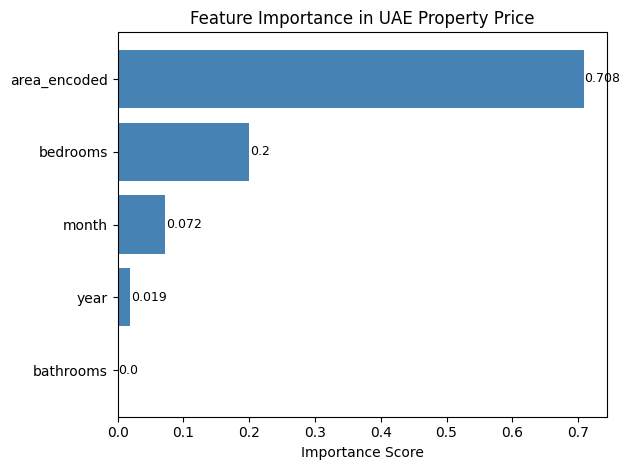

Feature Importance done


In [14]:
#Which feature affects price most?

importance = pd.DataFrame({"feature":["bathrooms","bedrooms",
"area_encoded","month","year"],"importance":rf.feature_importances_
})
#Sort by importance

importance = importance.sort_values("importance",ascending=True)
#Plot
plt.Figure(figsize=(10,6))
plt.barh(importance["feature"],
         importance["importance"],
         color="steelblue")
# add value labels
for i,v in enumerate(importance["importance"]):
    plt.text(v + 0.001,i,
            str(round(v,3)),
    va="center",
fontsize=9)
plt.title("Feature Importance in UAE Property Price")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importsance.png")
plt.show()
print("Feature Importance done")


